In [0]:
import os
import warnings
import cv2
import keras
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd
from PIL import Image
from keras import models, layers, optimizers
from keras.applications import VGG16
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, LSTM
from keras.models import Model, Sequential
from keras.preprocessing import image as image_utils
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from google.colab import drive
import tensorflow as tf
drive.mount('/content/drive')
% matplotlib inline
style.use('seaborn-whitegrid')
warnings.filterwarnings(action='once')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
gestures = {'L': 'Like',
           'fist': 'Caged',
           'C': 'C',
           'okay': 'Nice',
           'peace': 'Peace',
           'palm': 'Blessings',
            '0': 'Circle',
            '1': 'Released',
            '4': 'Four',
            'g': 'You',
            'i': 'I',
            'x': 'Bird',
            'y': 'Call',
            '7': 'Super',
            'q': 'Little',
            'r': 'Joined'
            }

gestures_map = {'Caged' : 0,
                'Like': 1,
                'Nice': 2,
                'Blessings': 3,
                'Peace': 4,
                'C': 5 ,
                'Circle': 6,
                'Released': 7,
                'Four': 8,
                'You': 9,
                'I': 10,
                'Bird':11,
                'Call':12,
                'Super':13,
                'Little':14,
                'Joined':15
                }

In [0]:
def process_image(path):
    img = cv2.imread(path)
    img =  cv2.resize(img, (224, 224), interpolation = cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = np.array(img)
    return img

def process_data(X_data, y_data):
    X_data = np.array(X_data, dtype = 'float32')
    if rgb:
        pass
    else:
        X_data = np.stack((X_data,)*3, axis=-1)
    X_data /= 255
    y_data = np.array(y_data)
    y_data = to_categorical(y_data)
    return X_data, y_data

def walk_file_tree(relative_path):
    X_data = []
    y_data = [] 
    for directory, subdirectories, files in os.walk(relative_path):
        for file in files:
            if not file.startswith('.'):
                path = os.path.join(directory, file)
                print('gestures',gestures)
                cl = file.split('_')[0]
                print('class',cl)
                gesture_name = gestures[cl]
                print('gesture name',gesture_name)
                y_data.append(gestures_map[gesture_name])
                X_data.append(process_image(path))   

            else:
                continue

    X_data, y_data = process_data(X_data, y_data)
    return X_data, y_data

In [0]:
relative_path = '/content/drive/My Drive/Colab Works/Training'
rgb = False

# # This method processes the data
X_data, y_data = walk_file_tree(relative_path)

gestures {'L': 'Like', 'fist': 'Caged', 'C': 'C', 'okay': 'Nice', 'peace': 'Peace', 'palm': 'Blessings', '0': 'Circle', '1': 'Released', '4': 'Four', 'g': 'You', 'i': 'I', 'x': 'Bird', 'y': 'Call', '7': 'Super', 'q': 'Little', 'r': 'Joined'}
class 0
gesture name Circle
gestures {'L': 'Like', 'fist': 'Caged', 'C': 'C', 'okay': 'Nice', 'peace': 'Peace', 'palm': 'Blessings', '0': 'Circle', '1': 'Released', '4': 'Four', 'g': 'You', 'i': 'I', 'x': 'Bird', 'y': 'Call', '7': 'Super', 'q': 'Little', 'r': 'Joined'}
class g
gesture name You
gestures {'L': 'Like', 'fist': 'Caged', 'C': 'C', 'okay': 'Nice', 'peace': 'Peace', 'palm': 'Blessings', '0': 'Circle', '1': 'Released', '4': 'Four', 'g': 'You', 'i': 'I', 'x': 'Bird', 'y': 'Call', '7': 'Super', 'q': 'Little', 'r': 'Joined'}
class q
gesture name Little
gestures {'L': 'Like', 'fist': 'Caged', 'C': 'C', 'okay': 'Nice', 'peace': 'Peace', 'palm': 'Blessings', '0': 'Circle', '1': 'Released', '4': 'Four', 'g': 'You', 'i': 'I', 'x': 'Bird', 'y': 'Ca

In [0]:
print(f'X_data shape: {X_data.shape}')
print(f'y_data shape: {y_data.shape}')

X_data shape: (960, 224, 224, 3)
y_data shape: (960, 16)


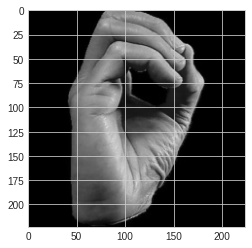

In [0]:
plt.imshow(X_data[0])

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.02, random_state=12, stratify=y_data)

In [0]:
file_path = '/content/drive/My Drive/Colab Works/saved_model.hdf5'
model_checkpoint = ModelCheckpoint(filepath=file_path, save_best_only=True)

early_stopping = EarlyStopping(monitor='val_acc',
                               min_delta=0,
                               patience=10,
                               verbose=1,
                               mode='auto',
                               restore_best_weights=True)

In [0]:
imageSize = 224
model = Sequential()
model.add(LSTM(128, return_sequences = True, input_shape = (224, 672)))
model.add(Flatten())
model.add(Dense(128, activation='relu', name='fc1'))
model.add(Dense(128, activation='relu', name='fc2'))
model.add(Dense(128, activation='relu', name='fc3'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu', name='fc4'))
model.add(Dense(16, activation='softmax'))

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(imageSize, imageSize, 3))
optimizer1 = optimizers.Adam()

callbacks_list = [keras.callbacks.EarlyStopping(monitor='val_acc', patience=3, verbose=1)]

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
X_data = np.reshape(X_data, (960,224,672))
model.fit(X_data, y_data, epochs=60, batch_size=10, validation_data=(X_data, y_data), verbose=1,
          callbacks=[early_stopping, model_checkpoint])

Train on 960 samples, validate on 960 samples
Epoch 1/60
960/960 [==============================] - 47s 49ms/step - loss: 2.2566 - accuracy: 0.2677 - val_loss: 1.2484 - val_accuracy: 0.5521


/usr/local/lib/python3.6/dist-packages/keras/callbacks/callbacks.py:846: RuntimeWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: val_loss,val_accuracy,loss,accuracy
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


Epoch 2/60
960/960 [==============================] - 47s 49ms/step - loss: 1.2687 - accuracy: 0.5781 - val_loss: 0.7527 - val_accuracy: 0.7156
Epoch 3/60
960/960 [==============================] - 47s 49ms/step - loss: 0.8581 - accuracy: 0.7146 - val_loss: 0.4520 - val_accuracy: 0.8667
Epoch 4/60
960/960 [==============================] - 47s 49ms/step - loss: 0.6518 - accuracy: 0.7646 - val_loss: 0.3481 - val_accuracy: 0.8958
Epoch 5/60
960/960 [==============================] - 47s 48ms/step - loss: 0.4801 - accuracy: 0.8333 - val_loss: 0.2050 - val_accuracy: 0.9344
Epoch 6/60
960/960 [==============================] - 47s 49ms/step - loss: 0.3673 - accuracy: 0.8740 - val_loss: 0.1532 - val_accuracy: 0.9479
Epoch 7/60
960/960 [==============================] - 46s 48ms/step - loss: 0.2987 - accuracy: 0.8938 - val_loss: 0.2420 - val_accuracy: 0.9396
Epoch 8/60
960/960 [==============================] - 46s 48ms/step - loss: 0.2436 - accuracy: 0.9177 - val_loss: 0.1856 - val_accuracy:

In [0]:
model.save('/content/drive/My Drive/Colab Works/gestmodelLS.h5')